In [15]:
import torch
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
import torchvision.transforms as transforms
import os
import pandas as pd
from PIL import Image
from collections import Counter

import spacy

from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import random_split
import matplotlib.pyplot as plt

In [14]:
spacy_eng = spacy.load("en_core_web_sm")

class Vocabulary:
    def __init__(self, freq_threshold):
        self.itos = {
            0: "<PAD>",
            1: "<SOS>",
            2: "<EOS>",
            3: "<UNK>"
        }

        self.stoi = {
            "<PAD>": 0,
            "<SOS>": 1,
            "<EOS>": 2,
            "<UNK>": 3
        }

        self.freq_threshold = freq_threshold

    def __len__(self):
        return len(self.itos)

    @staticmethod
    def tokenizer_eng(text):
        return [tok.text.lower() for tok in spacy_eng.tokenizer(text)]

    def build_vocabulary(self, sentence_list):
        frequencies = Counter()
        idx = 4

        for sentence in sentence_list:
            for word in self.tokenizer_eng(sentence):
                frequencies[word] += 1

                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1

    def numericalize(self, text):
        tokenized_text = self.tokenizer_eng(text)

        return [
            self.stoi[token] if token in self.stoi else self.stoi["<UNK>"]
            for token in tokenized_text
        ]

class FlickrDataset(Dataset):
    def __init__(self, root_dir, captions_file, transform=None, freq_threshold=5):
        self.root_dir = root_dir
        self.df = pd.read_csv(captions_file)

        self.transform = transform

        self.imgs = self.df["image"]
        self.captions = self.df["caption"]

        self.vocab = Vocabulary(freq_threshold)
        self.vocab.build_vocabulary(self.captions.tolist())

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        caption = self.captions[index]
        img_id = self.imgs[index]

        img = Image.open(os.path.join(self.root_dir, img_id)).convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        numericalized_caption = [self.vocab.stoi["<SOS>"]]

        numericalized_caption += self.vocab.numericalize(caption)

        numericalized_caption.append(self.vocab.stoi["<EOS>"])

        return img, torch.tensor(numericalized_caption)

class MyCollate:
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx

    def __call__(self, batch):
        imgs = [item[0].unsqueeze(0) for item in batch]

        imgs = torch.cat(imgs, dim=0)

        targets = [item[1] for item in batch]

        targets = pad_sequence(
            targets,
            batch_first=True,
            padding_value=self.pad_idx
        )

        return imgs, targets

def get_loader(
    root_folder,
    annotation_file,
    transform,
    batch_size=128,
    num_workers=0,
    shuffle=True,
    pin_memory=True,
):

    dataset = FlickrDataset(
        root_folder,
        annotation_file,
        transform=transform
    )

    pad_idx = dataset.vocab.stoi["<PAD>"]

    loader = DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        num_workers=num_workers,
        shuffle=shuffle,
        pin_memory=pin_memory,
        collate_fn=MyCollate(pad_idx=pad_idx),
    )

    return loader, dataset

def tokens_to_caption(tokens, vocab):

    words = []

    for token in tokens:

        word = vocab.itos[token]

        if word == "<EOS>":
            break

        if word not in ["<SOS>", "<PAD>"]:
            words.append(word)

    return " ".join(words)

Models

In [5]:
class EncoderCNN(nn.Module):
    def __init__(self, embed_size, train_CNN = False):
        super(EncoderCNN, self).__init__()
        self.train_CNN = train_CNN
        self.inception = models.inception_v3(weights=models.Inception_V3_Weights.DEFAULT, aux_logits=True)
        self.inception.aux_logits = False
        self.inception.AuxLogits = None
        self.inception.fc = nn.Linear(self.inception.fc.in_features, embed_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        for param in self.inception.parameters():
            param.requires_grad = train_CNN

        for param in self.inception.fc.parameters():
            param.requires_grad = True

    def forward(self, images):
        features = self.inception(images)
        return self.dropout(self.relu(features))


class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers):
        super(DecoderRNN, self).__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(0.5)

    def forward(self, features, captions):
        embeddings = self.dropout(self.embed(captions))
        features = features.unsqueeze(1)
        embeddings = torch.cat((features, embeddings), dim=1)
        hiddens, _ = self.lstm(embeddings)
        outputs = self.linear(hiddens)
        return outputs

class CNNtoRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers):
        super(CNNtoRNN, self).__init__()
        self.encoderCNN = EncoderCNN(embed_size)
        self.decoderRNN = DecoderRNN(embed_size, hidden_size, vocab_size, num_layers)

    def forward(self, images, captions):
        features = self.encoderCNN(images)
        outputs = self.decoderRNN(features, captions)
        return outputs

    def caption_image(self, image, vocabulary, max_length=50):
        result_caption = []
        self.eval()
        with torch.no_grad():
            x = self.encoderCNN(image).unsqueeze(0)
            states = None

            for _ in range(max_length):
                hiddens, states = self.decoderRNN.lstm(x, states)
                output = self.decoderRNN.linear(hiddens.squeeze(0))
                predicted = output.argmax(1)

                result_caption.append(predicted.item())
                x = self.decoderRNN.embed(predicted).unsqueeze(0)

                if vocabulary.itos[predicted.item()] == "<EOS>":
                    break
        self.train()
        return [vocabulary.itos[idx] for idx in result_caption]


Train

In [ ]:
transform = transforms.Compose(
    [
        transforms.Resize((356, 356)),
        transforms.RandomCrop((299,299)),
        transforms.ToTensor(),
        transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]),
    ]
)

# train_loader, dataset = get_loader(
#     root_folder="flickr8k/Images",
#     annotation_file="flickr8k/captions.txt",
#     transform=transform,
#     num_workers=0,
# )

full_dataset = FlickrDataset(
    root_dir="flickr8k/Images",
    captions_file = "flickr8k/captions.txt",
    transform = transform
)

train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(full_dataset,[train_size, val_size, test_size])
pad_idx = full_dataset.vocab.stoi["<PAD>"]

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    collate_fn=MyCollate(pad_idx)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    collate_fn=MyCollate(pad_idx)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    collate_fn=MyCollate(pad_idx)
)

torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#Hyperparamaters
embed_size = 256
hidden_size = 256
vocab_size = len(full_dataset.vocab)
num_layers = 1
learning_rate = 3e-4
num_epochs = 100


#initialize model, loss etc
model = CNNtoRNN(embed_size, hidden_size, vocab_size, num_layers).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=full_dataset.vocab.stoi["<PAD>"])
optimizer = optim.Adam(model.parameters(), lr = learning_rate)


max_loss = float('inf')
val_max_loss = float('inf')
noLossProgression = 0
indexLossProgression = 0
for epoch in range(num_epochs):
    #------------------------- TRAINING -------------------------
    model.train()
    running_loss = 0
    for idx, (imgs, captions) in enumerate(train_loader):
        imgs = imgs.to(device)
        captions = captions.to(device)

        outputs = model(imgs, captions[:, :-1])
        loss = criterion(outputs[:, 1:, :].reshape(-1, outputs.shape[2]), captions[:, 1:].reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
        optimizer.step()
        running_loss += loss.item()
    average_loss = running_loss/len(train_loader)
    #------------------------- VALIDATION -------------------------
    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for imgs, captions in val_loader:
            imgs = imgs.to(device)
            captions = captions.to(device)
            outputs = model(imgs, captions[:,:-1])
            val_loss = criterion(outputs[:, 1:, :].reshape(-1, outputs.shape[2]),captions[:, 1:].reshape(-1))
            val_running_loss += val_loss.item()
        val_average_loss = val_running_loss/len(val_loader)
        if val_average_loss <= val_max_loss:
                val_max_loss = val_average_loss
                torch.save(model.state_dict(), "BestModel.pth")
                print("Saved the Best Performing Model!")
                indexLossProgression = epoch +1
    print(f"Epoch [{epoch + 1}/{num_epochs}] Training Loss: {average_loss:.4f} Validation Loss: {val_average_loss:.4f}")
    if epoch >= 5 and epoch - indexLossProgression >= 5:
        break

Saved the Best Performing Model!
Epoch [1/100] Training Loss: 4.2141 Validation Loss: 3.6604
Saved the Best Performing Model!
Epoch [2/100] Training Loss: 3.5465 Validation Loss: 3.4021
Saved the Best Performing Model!
Epoch [3/100] Training Loss: 3.3311 Validation Loss: 3.2286
Saved the Best Performing Model!
Epoch [4/100] Training Loss: 3.1838 Validation Loss: 3.1207
Saved the Best Performing Model!
Epoch [5/100] Training Loss: 3.0777 Validation Loss: 3.0380
Saved the Best Performing Model!
Epoch [6/100] Training Loss: 2.9910 Validation Loss: 2.9693
Saved the Best Performing Model!
Epoch [7/100] Training Loss: 2.9204 Validation Loss: 2.9190
Saved the Best Performing Model!
Epoch [8/100] Training Loss: 2.8612 Validation Loss: 2.8776
Saved the Best Performing Model!
Epoch [9/100] Training Loss: 2.8125 Validation Loss: 2.8461
Saved the Best Performing Model!
Epoch [10/100] Training Loss: 2.7694 Validation Loss: 2.8160
Saved the Best Performing Model!
Epoch [11/100] Training Loss: 2.7302


----------------------------------
Actual Caption    : two large dogs and a small dog play in a lake .
Predicted Caption : two dogs are playing in the water . 


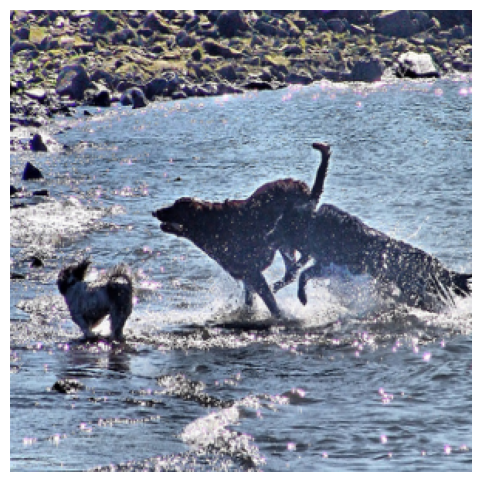


----------------------------------
Actual Caption    : two women with a baby stroller in a fancy restaurant .
Predicted Caption : people are walking down a street . 


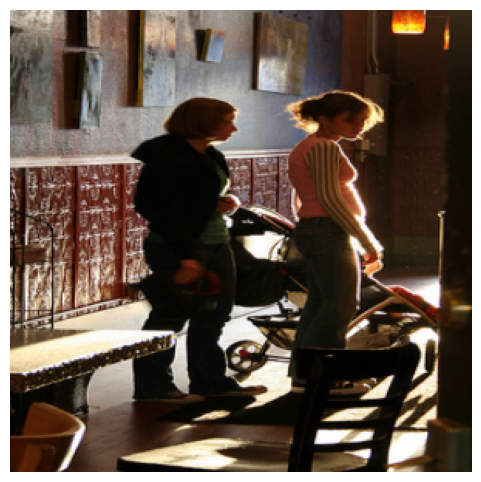


----------------------------------
Actual Caption    : two people ride together on a motorcycle
Predicted Caption : motorcycle racers on a dirt track . 


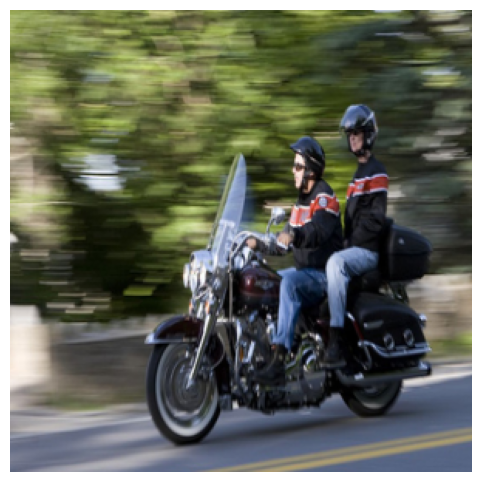


Final Test Loss: 2.7058


In [19]:
#Test the model
model.load_state_dict(torch.load("BestModel.pth"))
model.eval()

test_loss = 0.0
correct = 0
total = 0
test_running_loss = 0.0

with torch.no_grad():

    for batch_idx, (imgs, captions) in enumerate(test_loader):

        imgs = imgs.to(device)
        captions = captions.to(device)

        # Forward pass
        outputs = model(imgs, captions[:, :-1])

        # Compute test loss
        loss = criterion(outputs[:, 1:, :].reshape(-1, outputs.shape[2]), captions[:, 1:].reshape(-1))
        test_running_loss += loss.item()

        # Show a few predictions from first batch only
        if batch_idx == 0:

            for i in range(min(3, imgs.shape[0])):
                # Generate predicted caption
                predicted_caption = model.caption_image(imgs[i].unsqueeze(0), full_dataset.vocab)

                predicted_sentence = " ".join(predicted_caption)

                # Convert actual caption to text
                actual_sentence = tokens_to_caption(captions[i].cpu().numpy(), full_dataset.vocab)

                # Prepare image for matplotlib
                img = imgs[i].cpu()

                # Convert CHW -> HWC
                img = img.permute(1, 2, 0)

                # Undo normalization
                mean = torch.tensor([0.485, 0.456, 0.406])
                std = torch.tensor([0.229, 0.224, 0.225])

                img = img * std + mean
                img = img.clamp(0, 1)

                # Plot image
                plt.figure(figsize=(6, 6))
                plt.imshow(img)
                plt.axis("off")

                print("\n----------------------------------")
                print(f"Actual Caption    : {actual_sentence}")
                print(f"Predicted Caption : {predicted_sentence[:-5]}")

                plt.show()

# Average test loss
average_test_loss = test_running_loss / len(test_loader)

print(f"\nFinal Test Loss: {average_test_loss:.4f}")